In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

df = pd.read_csv('GermanCredit.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


Preprocessing

Drop the 3 columns that contribute the least to the dataset. These would be the columns with the highest number of non-zero 'none' values. Break ties by going left to right in columns. (Your code should be generalizable to drop n columns, but for the rest of the analysis, you can call your code for n=3.)

In [23]:
none_counts = (df == 'none').sum()

col_order = {col: i for i, col in enumerate(df.columns)}
priority = pd.DataFrame({'none_count': none_counts,
                          'col_pos':   [col_order[c] for c in none_counts.index]},
                         index=none_counts.index)
priority = priority.sort_values(['none_count', 'col_pos'], ascending=[False, True])

cols_to_drop = priority.index[:3].tolist()
print("Columns dropped:", cols_to_drop)
print("'none' counts:\n", priority.head(6))

df = df.drop(columns=cols_to_drop)
print("\nDataFrame shape after dropping:", df.shape)

Columns dropped: ['other_parties', 'other_payment_plans', 'own_telephone']
'none' counts:
                      none_count  col_pos
other_parties               907        9
other_payment_plans         814       13
own_telephone               596       18
checking_status               0        0
duration                      0        1
credit_history                0        2

DataFrame shape after dropping: (1000, 18)


Certain values in some of the columns contain unnecessary apostrophes (‘). Remove the apostrophes.

In [24]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace("'", "", regex=False)
print("Apostrophes removed from all object columns.")
df.head(3)

Apostrophes removed from all object columns.


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,residence_since,property_magnitude,age,housing,existing_credits,job,num_dependents,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,4,real estate,67,own,2,skilled,1,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,2,real estate,22,own,1,skilled,1,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,3,real estate,49,own,1,unskilled resident,2,yes,good


The checking_status column has values in 4 categories: 'no checking', '<0', '0<=X<200', and '>=200'. Change these to 'No Checking', 'Low', 'Medium', and 'High' respectively.

In [25]:
checking_map = {
    'no checking': 'No Checking',
    '<0':          'Low',
    '0<=X<200':    'Medium',
    '>=200':       'High'
}
df['checking_status'] = df['checking_status'].map(checking_map)
print(df['checking_status'].value_counts())

checking_status
No Checking    394
Low            274
Medium         269
High            63
Name: count, dtype: int64


The savings_status column has values in 4 categories: 'no known savings', '<100', '100<=X<500', '500<=X<1000', and '>=1000'. Change these to 'No Savings', 'Low', 'Medium', 'High', and 'High' respectively. (Yes, the last two are both 'High').

In [26]:
savings_map = {
    'no known savings': 'No Savings',
    '<100':             'Low',
    '100<=X<500':       'Medium',
    '500<=X<1000':      'High',
    '>=1000':           'High'
}
df['savings_status'] = df['savings_status'].map(savings_map)
print(df['savings_status'].value_counts())

savings_status
Low           603
No Savings    183
High          111
Medium        103
Name: count, dtype: int64


Change class column values from 'good' to '1' and 'bad' to '0'.

In [27]:
df['class'] = df['class'].map({'good': 1, 'bad': 0})
print(df['class'].value_counts())

class
1    700
0    300
Name: count, dtype: int64


Change the employment column value 'unemployed' to 'Unemployed', and for the others, change to 'Amateur', 'Professional', 'Experienced' and 'Expert', depending on year range.

In [28]:
employment_map = {
    'unemployed': 'Unemployed',
    '<1':         'Amateur',
    '1<=X<4':     'Professional',
    '4<=X<7':     'Experienced',
    '>=7':        'Expert'
}
df['employment'] = df['employment'].map(employment_map)
print(df['employment'].value_counts())

employment
Professional    339
Expert          253
Experienced     174
Amateur         172
Unemployed       62
Name: count, dtype: int64


Analysis

Often we need to find correlations between categorical attributes, i.e. attributes that have values that fall in one of several categories, such as "yes"/"no" for attr1, or "low","medium","high" for attr2.
One such correlation is to find counts in combinations of categorial values across attributes, as in how many instances are "yes" for attr1 and "low" for attr2. A good way to find such counts is to use the Pandas crosstab function. Do this for the following two counts.

In [29]:
ct1 = pd.crosstab(df['class'], df['foreign_worker'],
                  rownames=['class'], colnames=['foreign_worker'])
print(ct1)

foreign_worker  no  yes
class                  
0                4  296
1               33  667


In [30]:
ct2 = pd.crosstab(df['employment'], df['savings_status'],
                  rownames=['employment'], colnames=['savings_status'])
print(ct2)

savings_status  High  Low  Medium  No Savings
employment                                   
Amateur           12  120      17          23
Experienced       18  100      24          32
Expert            34  133      22          64
Professional      44  210      33          52
Unemployed         3   40       7          12


Find the average credit_amount of single males that have 4<=X<7 years of employment. You can leave the raw result as is, no need for rounding.

In [31]:
mask = (df['personal_status'] == 'male single') & (df['employment'] == 'Experienced')
avg_credit = df.loc[mask, 'credit_amount'].mean()
print(f"Average credit amount (single males, Experienced): {avg_credit}")

Average credit amount (single males, Experienced): 4142.592592592592


Find the average credit duration for each of the job types. You can leave the raw result as is, no need for rounding.

In [32]:
avg_duration = df.groupby('job')['duration'].mean()
print(avg_duration.to_string())

job
high qualif/self emp/mgmt    25.168919
skilled                      21.411111
unemp/unskilled non res      17.363636
unskilled resident           16.535000


For the purpose 'education', what is the most common checking_status and savings_status? Your code should print:
    Most common checking status: ...
    Most common savings status: ...

In [33]:
edu = df[df['purpose'] == 'education']
most_common_checking = edu['checking_status'].mode()[0]
most_common_savings  = edu['savings_status'].mode()[0]
print(f"Most common checking status: {most_common_checking}")
print(f"Most common savings status: {most_common_savings}")

Most common checking status: No Checking
Most common savings status: Low


Visualization

Plot subplots of two bar charts: one for savings_status (x-axis) to personal status (y-axis), and another for checking_status (x-axis) to personal_status (y-axis). In each of the charts, each personal status category bar (number of people in that category) should be of a different color.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct_savings = pd.crosstab(df['savings_status'], df['personal_status'])
ct_savings.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Savings Status vs Personal Status', fontsize=13)
axes[0].set_xlabel('Savings Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Personal Status', fontsize=7, title_fontsize=8)

ct_checking = pd.crosstab(df['checking_status'], df['personal_status'])
ct_checking.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Checking Status vs Personal Status', fontsize=13)
axes[1].set_xlabel('Checking Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Personal Status', fontsize=7, title_fontsize=8)

plt.suptitle('Savings & Checking Status by Personal Status', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

For people having credit_amount more than 4000, plot a bar graph which maps property_magnitude (x-axis) to the average customer age for that magnitude (y-axis).

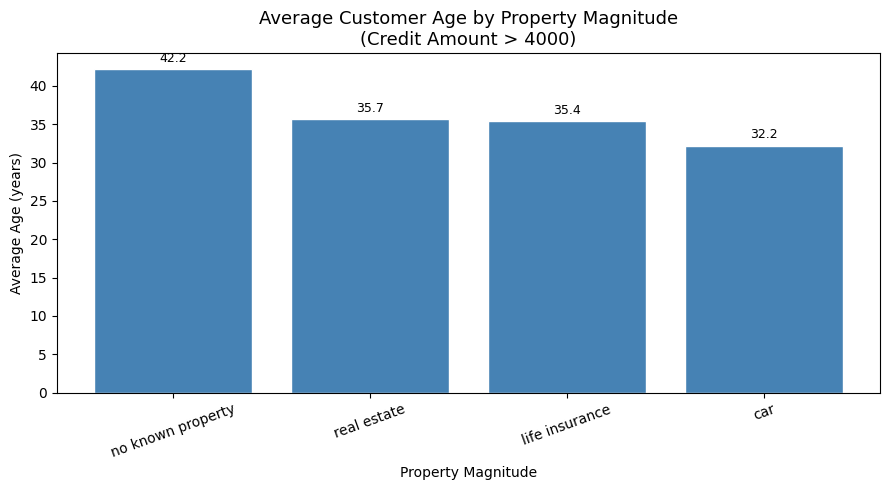

In [35]:
high_credit = df[df['credit_amount'] > 4000]
avg_age = high_credit.groupby('property_magnitude')['age'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_age.index, avg_age.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('Average Customer Age by Property Magnitude\n(Credit Amount > 4000)', fontsize=13)
ax.set_xlabel('Property Magnitude')
ax.set_ylabel('Average Age (years)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

For people with a "High" savings_status and age above 40, use subplots to plot the following pie charts:
Personal status
Credit history
Job

In [ ]:
subset = df[(df['savings_status'] == 'High') & (df['age'] > 40)]
print(f"Subset size: {len(subset)} rows")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(
        axes,
        ['personal_status', 'credit_history', 'job'],
        ['Personal Status', 'Credit History', 'Job']):
    counts = subset[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           startangle=140, textprops={'fontsize': 8})
    ax.set_title(title, fontsize=12)

plt.suptitle('High Savings Status & Age > 40 — Distribution Breakdown',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()